# A Hands-On Workshop: From Python Basics to Geospatial Mapping

---

| Section | Topics 
|---|---
| **Part 1A** | Python Fundamentals 
| **Part 1B** | Pandas & Datasets 
| **Part 1C** | Matplotlib
| **Part 1D** | Seaborn + Stats 
| **Part 2A** | GeoPandas & Shapefiles 
| **Part 2B** | Projections 
| **Part 2C** | Interactive Maps with Folium 
| **Part 2D** | Choropleth Maps & Professional Layouts 

---

> **Setup check:** Run the cell below to make sure your environment is ready.


In [161]:
# ✅ Environment Setup — Run this first!
import sys
required = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'geopandas', 'folium', 'geodatasets', 'mapclassify']
missing = []
for pkg in required:
    try:
        __import__(pkg)
        print(f"  ✓ {pkg}")
    except ImportError:
        missing.append(pkg)
        print(f"  ✗ {pkg}  ← MISSING")

if missing:
    print(f"\n⚠️  Install missing packages with:")
    print(f"  pip install {' '.join(missing)}")
else:
    print("\n🎉 All packages ready!")


  ✓ numpy
  ✓ pandas
  ✓ matplotlib
  ✓ seaborn
  ✓ geopandas
  ✓ folium
  ✓ geodatasets
  ✓ mapclassify

🎉 All packages ready!


---
# 🎨 Part 1D — Seaborn & Statistical Visualization

**Seaborn** is built *on top of* matplotlib and is designed specifically for statistical graphics. It:
- Works natively with pandas DataFrames
- Has beautiful default aesthetics
- Makes complex statistical plots easy
- Automatically computes confidence intervals, KDEs, etc.

Think of matplotlib as the *brush and canvas*, seaborn as the *paint-by-numbers kit*.


In [2]:
import seaborn as sns

# Seaborn themes
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
print("Seaborn version:", sns.__version__)

# Load the iris dataset — a classic for visualization
iris = sns.load_dataset("iris")
print(iris.head())
print("\nShape:", iris.shape)
print("Species:", iris['species'].unique())

# Also load the tips dataset (same as in Part 1)
df = sns.load_dataset("tips")
# Calculate tips_pct and add as a new column
df['tip_pct'] = df['tip'] / df['total_bill'] * 100


Seaborn version: 0.13.2
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Shape: (150, 5)
Species: <StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str


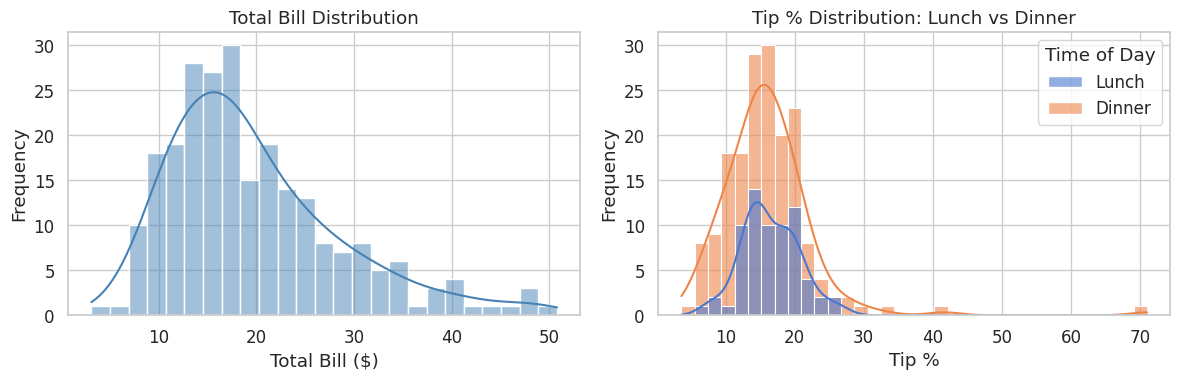

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── displot / histplot — distribution with stats ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) # Using fig and axes for more control and subplots with 1 row and 2 columns

# histplot with KDE
sns.histplot(data=df, x='total_bill', kde=True, bins=25, ax=axes[0], color='steelblue')
axes[0].set_title('Total Bill Distribution')
axes[0].set_xlabel('Total Bill ($)')
axes[0].set_ylabel('Frequency')

# By group — overlapping histograms
sns.histplot(data=df, x='tip_pct', hue='time', kde=True, bins=35, ax=axes[1], alpha=0.6) # kde=True adds a density curve
axes[1].set_title('Tip % Distribution: Lunch vs Dinner')
axes[1].set_xlabel('Tip %')
axes[1].set_ylabel('Frequency') 
#axes[1].legend(title='Time of Day')
plt.gca().get_legend().set_title('Time of Day') 

plt.tight_layout()
plt.show()


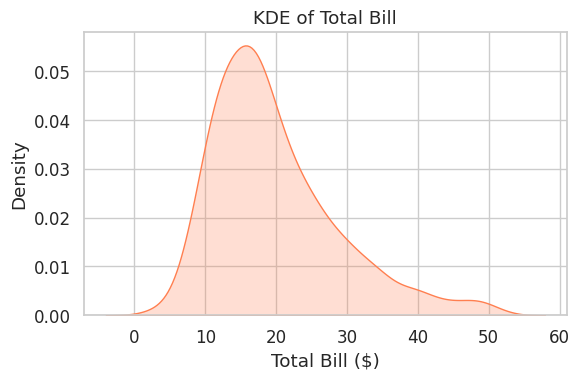

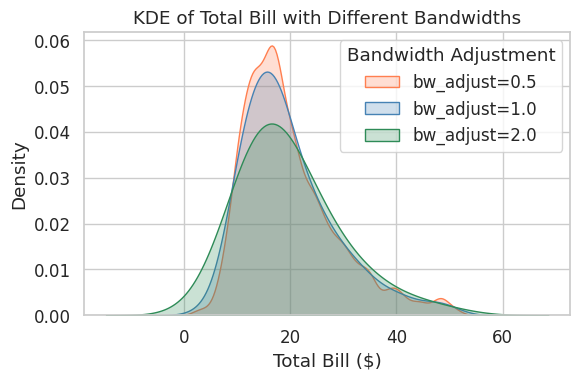

In [18]:
# Kernel Density Estimate (KDE) plot
# Change the bandwidth (bw_adjust) to see how it affects the smoothness of the curve
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df, x='total_bill', fill=True, bw_adjust=0.8, color='coral')
plt.title('KDE of Total Bill')
plt.xlabel('Total Bill ($)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()  

# An overlay showing KDEs with different bandwidths
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df, x='total_bill', fill=True, bw_adjust=0.5, color='coral', label='bw_adjust=0.5')
sns.kdeplot(data=df, x='total_bill', fill=True, bw_adjust=1.0, color='steelblue', label='bw_adjust=1.0')
sns.kdeplot(data=df, x='total_bill', fill=True, bw_adjust=2.0, color='seagreen', label='bw_adjust=2.0')
plt.title('KDE of Total Bill with Different Bandwidths')        
plt.xlabel('Total Bill ($)')
plt.ylabel('Density')
plt.legend(title='Bandwidth Adjustment')
plt.tight_layout()
plt.show()

 

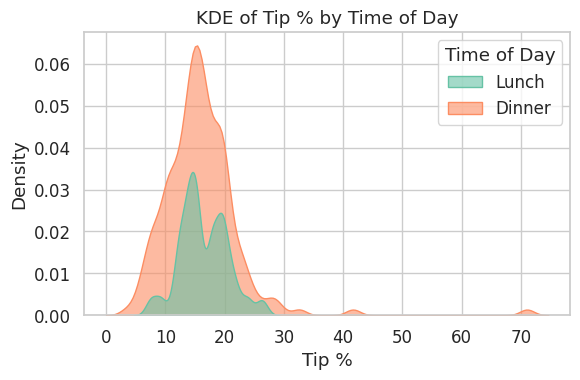

In [165]:
# By group — KDE with hue
plt.figure(figsize=(6, 4))
sns.kdeplot(data=df, x='tip_pct', hue='time', fill=True, bw_adjust=0.5, alpha=0.6, palette='Set2')
plt.title('KDE of Tip % by Time of Day')
plt.xlabel('Tip %')
plt.ylabel('Density')
# Legend is automatically created by hue, but we can customize it
# This is not done using the standard plt.legend() since seaborn handles it internally when using hue
# Instead, we can set the title of the legend using the legend method of the axes object
plt.gca().get_legend().set_title('Time of Day')  # here plt.gca() gets the current axes, and get_legend() gets the legend object to set its title
plt.tight_layout()
plt.show() 

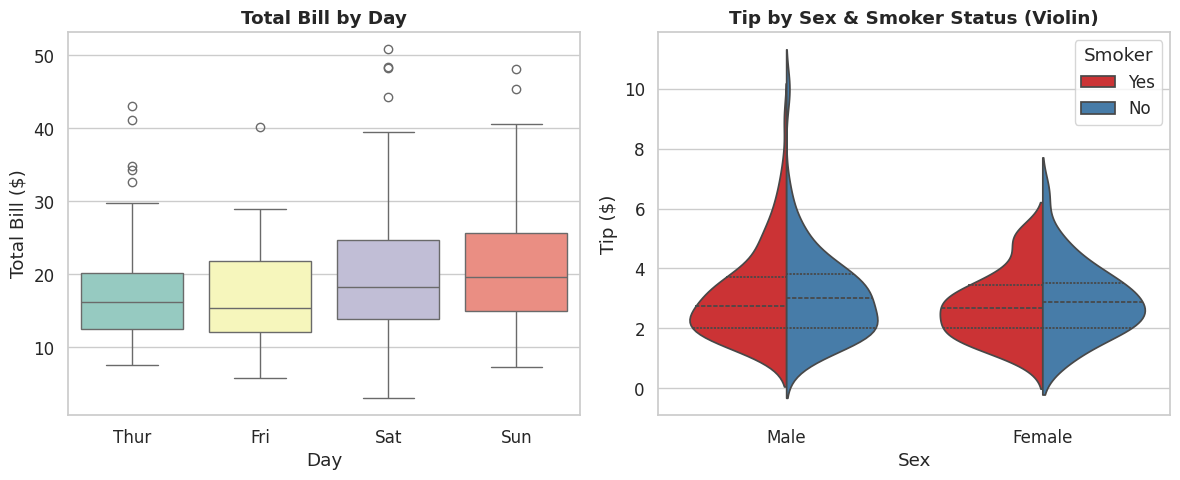

In [166]:
# ── Box Plot — the statistician's favorite ──────────────────────────────────
# Box plots show: median, IQR, whiskers (1.5×IQR), and outliers

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: bill by day
#sns.boxplot(data=df, x='day', y='total_bill', order=['Thur','Fri','Sat','Sun'], ax=axes[0]) # use ax to specify which subplot to draw on
# Same as above but with a pallete changing the color of the boxes. Note we set legend=False and dodge=False to avoid creating a separate legend for the hue variable 
# and to keep the boxes together by day instead of splitting them by hue
sns.boxplot(data=df, x='day', y='total_bill', order=['Thur','Fri','Sat','Sun'], hue='day', palette='Set3', ax=axes[0], legend=False, dodge=False) 
axes[0].set_title('Total Bill by Day', fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Total Bill ($)')

# Right: violin plot (shows full distribution shape, not just summary)
sns.violinplot(data=df, x='sex', y='tip', hue='smoker', split=True, palette='Set1', ax=axes[1], inner='quart') # split=True creates a split violin for the hue 
# variable, inner='quart' adds lines for the quartiles
axes[1].set_title('Tip by Sex & Smoker Status (Violin)', fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Tip ($)')
axes[1].legend(title='Smoker', loc='upper right')

plt.tight_layout()
plt.show()


### 📊 Statistical Concept: Box Plots

A box plot (box-and-whisker plot) is a compact summary of a distribution:

```
    whisker      Q1     median     Q3    whisker
       |         |        |        |       |
  ─────┼─────────┤████████│████████├───────┼──── ● (outlier)
       |         |        |        |       |
  
  Whiskers extend to 1.5 × IQR from Q1/Q3
  Points beyond whiskers = potential outliers
```

**IQR = Q3 - Q1** = the "interquartile range" = the middle 50% of the data.


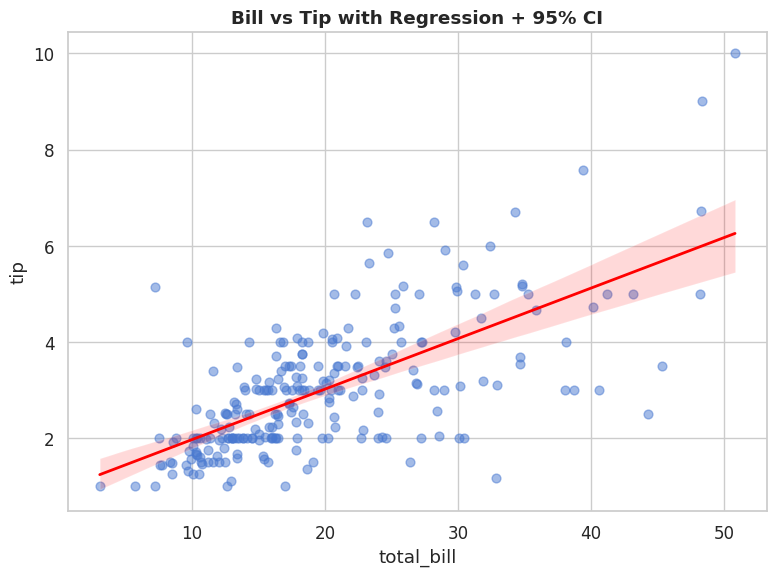

In [167]:
import numpy as np

# ── Scatter with regression line (lmplot / regplot) ─────────────────────────
plt.figure(figsize=(8,6))

# regplot adds a regression line + confidence interval automatically
sns.regplot(data=df, x='total_bill', y='tip', # provide data variables for x and y
            scatter_kws={'alpha': 0.5, 's': 40}, # customize scatter points with alpha for transparency and size
            line_kws={'color': 'red', 'linewidth': 2}, # customize the regression line with color and width
            ci=95)   # 95% confidence interval shown as shaded band
plt.title('Bill vs Tip with Regression + 95% CI', fontweight='bold')
# Change background color and grid style. Lets use a grey background with white grid lines for better contrast. 
# We can also increase the font size for better readability.
sns.set_context("notebook", font_scale=1.2) # larger font for better readability
sns.set_style("darkgrid", {'axes.facecolor': '#EAEAF2', 'grid.color': 'white'}) # grey background with white grid lines
plt.tight_layout()
plt.show()


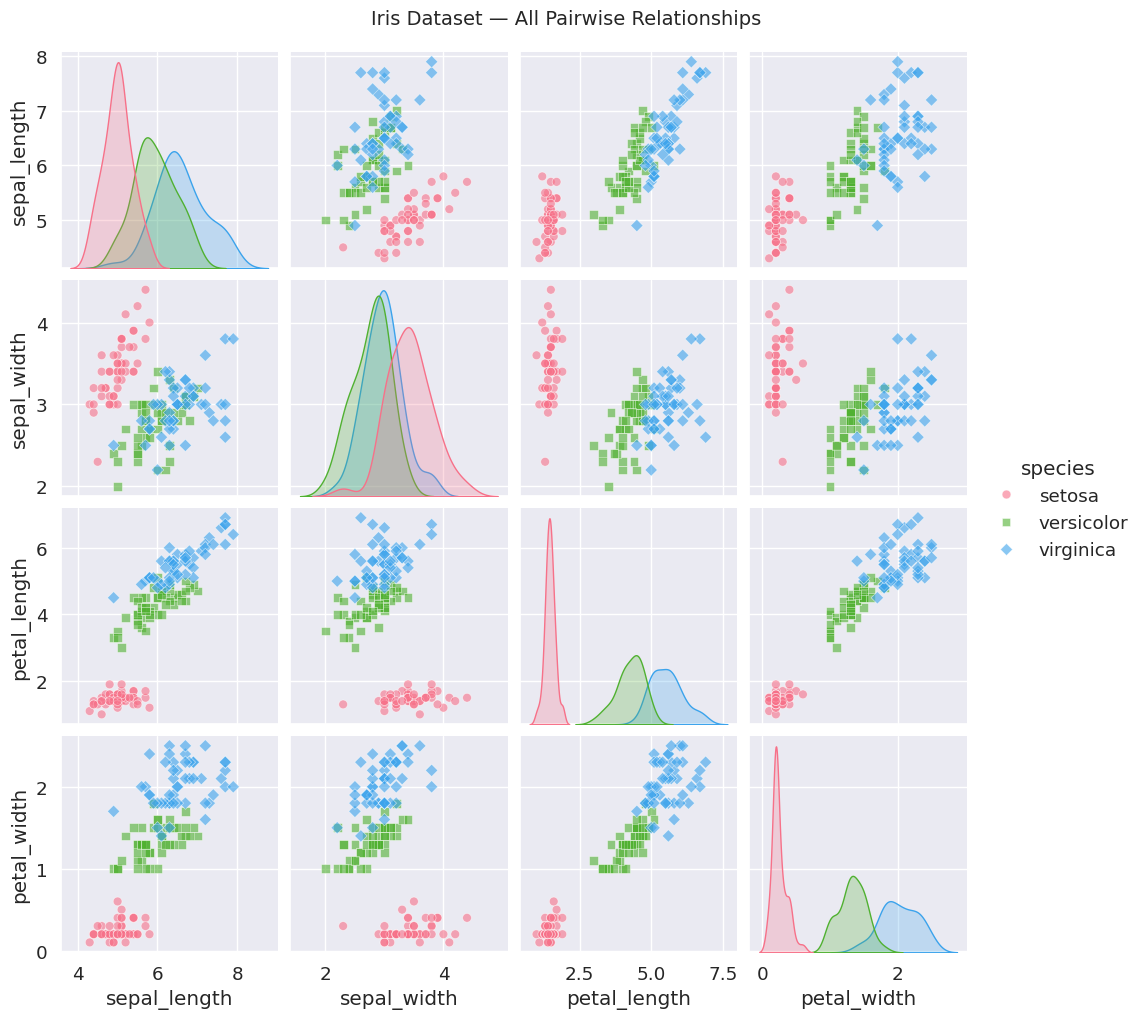

In [168]:
# ── Pair Plot — explore ALL variable relationships at once ───────────────────
# This is incredibly useful for initial EDA!

g = sns.pairplot(iris, hue='species', # color by species
                 markers=['o', 's', 'D'], # different marker for each species
                 diag_kind='kde',            # distribution on diagonal. other options are 'hist' or 'auto'
                 plot_kws={'alpha': 0.6, 's': 40}, # customize scatter points with alpha for transparency and size
                 palette='husl')
g.figure.suptitle('Iris Dataset — All Pairwise Relationships', y=1.02, fontsize=14)
plt.show()


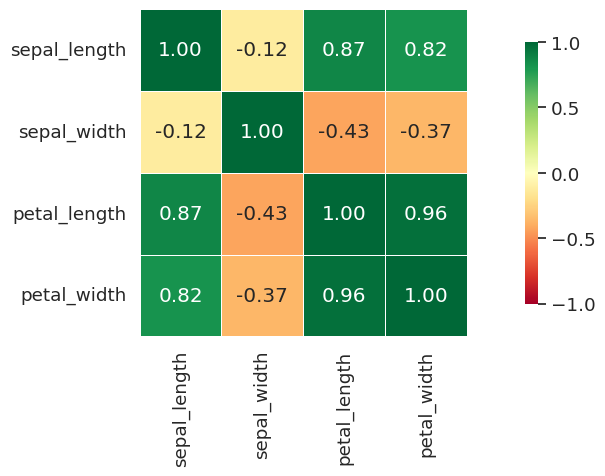

In [169]:
# ── Heatmap — visualizing correlation matrices ───────────────
plt.figure(figsize=(12, 5))

# Left: correlation heatmap
numeric_cols = iris.select_dtypes(include='number') # select only numeric columns for correlation
corr = numeric_cols.corr() # compute correlation matrix for numeric columns

sns.heatmap(corr, annot=True, fmt='.2f', 
            cmap='RdYlGn', center=0, vmin=-1, vmax=1, # cmap controls colors, center=0 makes 0 correlation yellow, vmin/vmax set the range of the colormap
            square=True, linewidths=0.5, # square=True makes cells square, linewidths adds lines between cells
            cbar_kws={'shrink': 0.8}) # cbar_kws customizes the colorbar, here we shrink it to 80% of its default size
axes[0].set_title('Iris Feature Correlations', fontweight='bold')

plt.tight_layout()
plt.show()


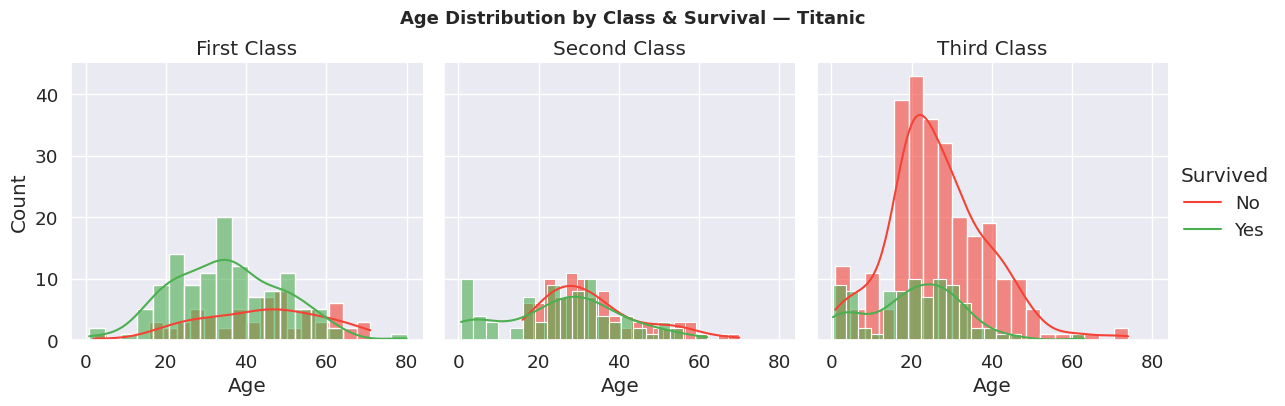

In [170]:
# ── FacetGrid — same plot, many subgroups ────────────────────────────────────
titanic = sns.load_dataset("titanic")

# Distribution of age by class and survival
g = sns.FacetGrid(titanic, col='class', hue='survived', # using a different dataset here - titanic deaths by class and survival
                  palette={1:'#4CAF50', 0:'#F44336'}, # green for survived, red for not survived
                  col_order=['First','Second','Third'], height=4) # col_order ensures the classes are in the correct order instead of alphabetical
g.map(sns.histplot, 'age', kde=True, bins=20, alpha=0.6) # map() applies the same plot (here histplot) to each facet (class) and hue (survived)
g.add_legend(title='Survived', labels=['No','Yes']) 
g.set_axis_labels('Age', 'Count')
g.set_titles(col_template='{col_name} Class') # col_template allows us to customize the title of each facet using the column name (class in this case)
# notice that we are using the {} syntax - similar to f-strings but with the column name instead of a variable
g.figure.suptitle('Age Distribution by Class & Survival — Titanic', # overall title for the entire FacetGrid
                  y=1.02, fontsize=13, fontweight='bold')
plt.show()


---
---
# 🗺️ PART 2 — Geospatial Data Analysis
## From Shapefiles to Interactive Maps

---

| Section | Topics |
|---|---|
| **2A** | GeoPandas fundamentals, loading shapefiles |
| **2B** | WFS feeds, coordinate reference systems |
| **2C** | Interactive maps with Folium |
| **2D** | Choropleth maps & professional cartography |



---
# 🌍 Part 2A — GeoPandas & Shapefiles

**GeoPandas** extends pandas to support geographic/spatial operations. A `GeoDataFrame` is just a DataFrame with a special `geometry` column.

```
pip install geopandas geodatasets
```

### Common vector data formats:
| Format | Extension | Notes |
|--------|-----------|-------|
| **Shapefile** | `.shp` (+.dbf, .prj, .shx) | Legacy, widely used |
| **GeoJSON** | `.geojson` | Web-friendly, human-readable |
| **GeoPackage** | `.gpkg` | Modern, single-file, recommended |
| **WFS** | URL | Web Feature Service — live data from a server |


In [171]:
%pip install matplotlib_scalebar

Note: you may need to restart the kernel to use updated packages.


In [22]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar
import numpy as np
import pandas as pd

print(f"GeoPandas version: {gpd.__version__}")


GeoPandas version: 1.1.2


In [23]:
# ── Loading a local shapefile ─────────────────────────────────────────────────
# In practice, you'll load your own data like this:
#   gdf = gpd.read_file("path/to/your/data.shp")
#   gdf = gpd.read_file("path/to/your/data.geojson")
#   gdf = gpd.read_file("path/to/your/data.gpkg")

# For this workshop, let's download US states from Census Bureau
import urllib.request, io

print("Downloading US States shapefile orignally obtatined from the US Census Bureau...")
url = "https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json"
try:
    with urllib.request.urlopen(url, timeout=10) as response: # this is boilerplate code to download data from a URL with a timeout to avoid hanging 
        # if the network is unavailable
        data = response.read() # store the downloaded data in a variable called data
    states = gpd.read_file(io.BytesIO(data)) # create a GeoDataFrame from the downloaded data using GeoPandas read_file function, 
    # which can read from a file-like object created by io.BytesIO. You will use the same function to read from a file path when you load your own data, 
    # but here we are reading from the downloaded data in memory instead of a file on disk.
    print(f"  Loaded {len(states)} states")
    print(f"  CRS: {states.crs}") # This prints the EPSG code associated with the coordinate reference system (CRS) of the GeoDataFrame, 
    # which is important for understanding the spatial reference and for performing spatial operations correctly. Note: data MUST be in a projected CRS 
    # (not geographic) for accurate area and distance calculations, so you may need to reproject your data using states.to_crs(epsg=your_epsg_code) if 
    # it's not already in a projected CRS. In this case, EPSG:4326 is a geographic CRS (latitude/longitude), so we will reproject it later to a projected 
    # CRS for accurate area calculations.
    print(f"  Columns: {list(states.columns)}")
except Exception as e:
    print(f" Network unavailable: {e}")
    

  Loaded 52 states
  CRS: EPSG:4326
  Columns: ['id', 'name', 'density', 'geometry']


In [25]:
# ── Spatial operations — the power of GeoPandas ──────────────────────────────

# 1. AREA — how big is each geometry?
# Project to equal-area CRS first (important for accurate area calculation!)
# Lets project the US states data to an equal area projection. We can use the 
# US National Atlas Equal Area projection (EPSG:2163) which is commonly used for US data
states_equal_area = states.to_crs("EPSG:2163")   # Reproject to US National Atlas Equal Area
states['area_km2'] = states_equal_area.geometry.area / 1e6  # m² → km²

# Now lets print the top 5 largest states by area
top5 = states.nlargest(5, 'area_km2')[['name', 'area_km2']].reset_index(drop=True) # nlargest() gets the top 5 rows with largest area_km2, and we select 
# only the name and area_km2 columns for display. reset_index(drop=True) resets the index to be sequential starting from 0, and drop=True means 
# we don't keep the old index as a column.
print("5 Largest US States by Area:")
print(top5)  

# 2. BOUNDS — bounding box of each geometry for Georgia
print("\nBounding box of world extent:")
# Filter Georgia from the states GeoDataFrame
georgia = states[states['name'] == 'Georgia'] # Note we are using states - so coordinates are in lat/lon (EPSG:4326) which is not ideal for 
# area calculations but is fine for bounding box since it's just the min/max lat/lon. If we were to calculate area or distance, we would need to 
# use the reprojected states_equal_area GeoDataFrame instead which is in a projected CRS (EPSG:2163) that uses meters as units. 
print(f"  Georgia bounds: {georgia.total_bounds}")   # [minx, miny, maxx, maxy]
georgia_projected = georgia.to_crs("EPSG:2163") # reproject Georgia to the same equal area projection for accurate area and distance calculations
print(f"  Georgia bounds (projected): {georgia_projected.total_bounds}") # bounding box in projected coordinates (meters) which is more accurate for distance 
# calculations than the lat/lon


5 Largest US States by Area:
         name      area_km2
0      Alaska  1.518956e+06
1       Texas  6.871575e+05
2  California  4.096115e+05
3     Montana  3.809714e+05
4  New Mexico  3.143241e+05

Bounding box of world extent:
  Georgia bounds: [-85.606675  30.356734 -80.885553  35.00118 ]
  Georgia bounds (projected): [ 1308498.83650363 -1457022.82574238  1795056.91939321  -956645.36306363]


In [26]:
# 3. CENTROID — center point of each polygon in the states_equal_area GeoDataFrame for accurate centroid calculation in projected coordinates
states_equal_area['centroid'] = states_equal_area.geometry.centroid
print("\nExample centroids:")
print(states_equal_area[['name', 'centroid']].head())




Example centroids:
         name                           centroid
0     Alabama   POINT (1232070.011 -1260985.933)
1      Alaska    POINT (-2311072.137 2963243.36)
2     Arizona  POINT (-1071176.169 -1116195.106)
3    Arkansas     POINT (690516.42 -1090474.473)
4  California    POINT (-1707964.483 -666275.66)


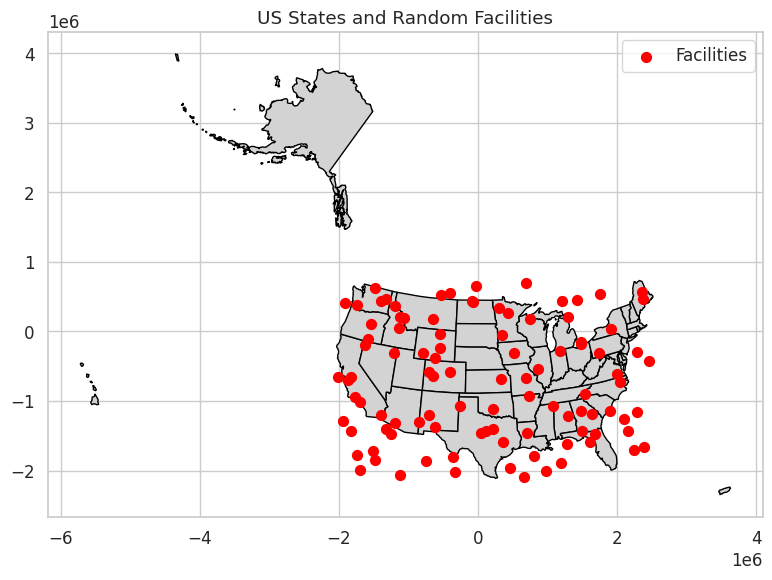

In [27]:
# 4. SPATIAL JOIN — combine data from two GeoDataFrames based on location
# This is like SQL JOIN but for geometry relationships!

# Create some random "facilities" (points) across the US for demonstration
num_facilities = 100
# Lets exclude Alaska and Hawaii from the random point generation by using the bounding box of the contiguous US states instead of the entire US.
states_equal_area_contiguous = states_equal_area[~states_equal_area['name'].isin(['Alaska', 'Hawaii', 'Puerto Rico'])] # filter out Alaska, Hawaii, and Puerto Rico to get only the contiguous US states for random point generation
minx, miny, maxx, maxy = states_equal_area_contiguous.total_bounds # get the bounding box of the contiguous US states to generate random points within this area
np.random.seed(42) # for reproducibility
random_points = gpd.GeoDataFrame({
    'facility_id': range(num_facilities), # unique ID for each facility
    'geometry': gpd.points_from_xy(
        np.random.uniform(minx, maxx, num_facilities),
        np.random.uniform(miny, maxy, num_facilities)
    ) # generate random points within the bounding box of the states using uniform distribution for x and y coordinates
}, crs="EPSG:2163") # set the CRS to the same equal area projection as states_equal_area for accurate spatial operations

# Plot the states and facilities to visualize
fig, ax = plt.subplots(figsize=(10, 6)) # Using matplotlib to plot the states and random facilities - pretty cool eh! 
states_equal_area.plot(ax=ax, color='lightgray', edgecolor='black') # plot function of the states GeoDataFrame to draw the state boundaries, 
# with light gray fill and black edges
random_points.plot(ax=ax, color='red', markersize=50, label='Facilities') # plot random facilities as red points
plt.title('US States and Random Facilities')
plt.legend()
plt.tight_layout()


In [28]:
# Spatial join: which state is each facility located in?
# We use a spatial join to find out which state polygon each facility point falls within. This is done using the sjoin function from GeoPandas, 
# which performs a spatial join based on the geometry of the two GeoDataFrames. The 'within' predicate means we are looking for points that are 
# within the polygons of the states.
joined = gpd.sjoin(random_points, states_equal_area[['name', 'geometry']], how='left', predicate='within') # this will add a 'name' column to the joined GeoDataFrame indicating which state each facility is in
# Drop any null values in the 'name' column which indicate facilities that are not within any state polygon (e.g., if they were generated outside the bounding box or in water)
joined = joined.dropna(subset=['name']) # subset=['name'] means we are only looking at null values in the 'name' column, and dropna() will remove those rows from the joined GeoDataFrame
print("\nFacilities with their corresponding states:")
print(joined[['facility_id', 'name']].head())   


Facilities with their corresponding states:
   facility_id        name
2            2     Alabama
3            3    Missouri
4            4  Washington
6            6  California
7            7    New York


---
# 🌐 Part 2B — Coordinate Reference Systems
```
Coordinate Reference Systems (CRS) — the most important concept in GIS!

Every geospatial dataset uses a **CRS** (also called a *projection*) to define how 2D map coordinates relate to the actual 3D Earth.

| CRS | EPSG Code | Use Case |
|-----|-----------|----------|
| WGS84 (geographic) | 4326 | GPS, web maps, global data |
| Web Mercator | 3857 | Google Maps, OpenStreetMap tiles |
| USA Albers Equal Area | 5070 | Thematic maps of the US |
| Georgia NAD83 | 26967 | Georgia state data |
| UTM Zone 17N | 32617 | SE United States measurements |


In [29]:
# ── Why projections matter: area distortion ──────────────────────────────────
# Different projections distort different properties (area, shape, distance)

# Let's compare how the area of Texas changes under different projections to see the effect of projection on area calculations. 
# We will calculate the area of Texas in both the original geographic CRS (EPSG:4326) and the projected equal area CRS (EPSG:2163) 
# to demonstrate how using a geographic CRS can lead to inaccurate area calculations due to distortion, while using a projected CRS 
# designed for area preservation gives us a more accurate measurement.

# Get Texas geometry
texas = states[states['name'] == 'Texas']
texas_equal_area = texas.to_crs("EPSG:2163") # reproject Texas to the same equal area projection for accurate area calculation
area_geographic = texas.geometry.area.iloc[0]  # area using geographic CRS (this will be inaccurate due to distortion). iloc[0] is used to 
# get the area value from the first (and only) row of the texas GeoDataFrame, since area is calculated for each geometry and we have only one geometry for Texas.
area_equal_area = texas_equal_area.geometry.area.iloc[0] / 1e6 # area in km² using equal area projection (this will be more accurate)

print(f"\nArea of Texas in geographic CRS (EPSG:4326): {area_geographic:.2f} decimal degree square! (inaccurate due to distortion)")
print(f"Area of Texas in equal area projection (EPSG:2163): {area_equal_area:.2f} km² (more accurate)")


Area of Texas in geographic CRS (EPSG:4326): 65.18 decimal degree square! (inaccurate due to distortion)
Area of Texas in equal area projection (EPSG:2163): 687157.54 km² (more accurate)


/tmp/ipykernel_88516/2462494043.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area_geographic = texas.geometry.area.iloc[0]  # area using geographic CRS (this will be inaccurate due to distortion). iloc[0] is used to


---
# 🗺️ Part 2C — Interactive Maps with Folium

**Folium** wraps the popular **Leaflet.js** library (the same engine behind OpenStreetMap and many web GIS tools) into Python. The result: fully interactive, zoomable, clickable maps rendered as HTML.

| Feature | GeoPandas `.plot()` | GeoPandas `.explore()` | Folium |
|---------|--------------------|-----------------------|--------|
| Static/Interactive | Static | Interactive ✓ | Interactive ✓ |
| Ease of use | ⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ |
| Customization | ⭐⭐⭐ | ⭐⭐ | ⭐⭐⭐ |
| Basemaps | ✗ | ✓ | ✓ |
| Offline | ✓ | ✗ | ✗ |
| Publishable HTML | ✗ | Limited | ✓ |


In [30]:
import folium
from folium import plugins
from folium.plugins import HeatMap, MarkerCluster

print(f"Folium version: {folium.__version__}")


Folium version: 0.20.0


In [31]:
# ── GeoPandas .explore() — the quick interactive map ─────────────────────────
# .explore() is the fastest way to get an interactive view of any GeoDataFrame

# Let's use the states GeoDataFrame we loaded earlier to create an interactive map of US states using the .explore() method. 
# This will allow us to quickly visualize the spatial data without needing to set up a full Folium map from scratch.

states.explore()

In [32]:
# ── Building a Folium map from scratch ───────────────────────────────────────
# More control than .explore()

# Atlanta coordinates
ATLANTA = [33.749, -84.388] 

# Create a base map
m2 = folium.Map(
    location=ATLANTA,
    zoom_start=15, # zoom level (higher = closer)
    tiles='CartoDB positron'    # clean basemap
)

# ── Add tile layer options ────────────────────────────────────────────────────
# Users can switch between basemaps with the layer control
# Tiles are the base map layers that provide the background geographic context for your map. They are typically provided by 
# third-party services and can include different styles such as street maps, satellite imagery, terrain, etc. 
# Adding multiple tile layers allows users to switch between different basemap styles using the layer control, 
# enhancing the interactivity and usability of the map. Each tile layer requires proper attribution to comply with the terms of use of the 
# tile provider, which is why we include the attr parameter when adding tile layers in Folium.
folium.TileLayer('OpenStreetMap', name='Street Map', attr='OpenStreetMap').add_to(m2)
folium.TileLayer('CartoDB dark_matter', name='Dark', attr='CartoDB').add_to(m2)

# ── Add markers ───────────────────────────────────────────────────────────────
# Georgia State University campus buildings
gsu_locations = [
    {"name": "Aderhold Learning Center", "lat": 33.7525, "lon": -84.3883, "type": "Academic"},
    {"name": "Student Center East",      "lat": 33.7531, "lon": -84.3874, "type": "Student Life"},
    {"name": "Andrew Young School",      "lat": 33.7533, "lon": -84.3879, "type": "Academic"},
    {"name": "Centennial Hall",          "lat": 33.7550, "lon": -84.3866, "type": "Housing"},
    {"name": "Langdale Hall",            "lat": 33.7518, "lon": -84.3895, "type": "Academic"},
    {"name": "Georgia State Stadium",    "lat": 33.7553, "lon": -84.4016, "type": "Athletics"},
] # This is a list of dictionaries, where each dictionary represents a location on the GSU campus with its name, latitude, longitude, and 
# type (e.g., Academic, Student Life, Housing, Athletics). We will use this data to add markers to our Folium map.

# Different marker colors by type
type_colors = {"Academic": "blue", "Student Life": "green", 
               "Housing": "orange", "Athletics": "red"} # dictionary mapping each type of location to a specific color for the markers on the map. 

for loc in gsu_locations:
    folium.CircleMarker(
        location=[loc['lat'], loc['lon']], # Extract the latitude and longitude from the loc dictionary to set the location of the marker on the map.
        radius=10, # Size of the marker
        color=type_colors[loc['type']], # Use colors from the type_colors dictionary based on the type of location
        fill=True, fill_opacity=0.8, # Set fill to True and adjust opacity for better visibility
        popup=folium.Popup(
            f"""<b>{loc['name']}</b><br>
            Type: {loc['type']}<br>
            Lat: {loc['lat']:.4f}, Lon: {loc['lon']:.4f}""",
            max_width=200
        ), # Creates a popup using HTML formatting to display the name, type, and coordinates of the location when the marker is clicked. 
        #max_width limits the width of the popup for better readability.
        tooltip=loc['name'] # What you see when you hover over the marker without clicking - in this case, we show the name of the location as a tooltip.
    ).add_to(m2)

# Add layer control (lets users toggle layers)
folium.LayerControl().add_to(m2)

m2.save('/tmp/gsu_map.html')
print("GSU map created!")
m2


GSU map created!


In [33]:
# ── MarkerCluster — handle many points without clutter ───────────────────────
# Create 200 random "incident" points around Atlanta
np.random.seed(42)
n_incidents = 200
incident_lats = np.random.normal(33.749, 0.08, n_incidents)
incident_lons = np.random.normal(-84.388, 0.10, n_incidents)
incident_types = np.random.choice(
    ['Traffic', 'Power Outage', 'Water Main', 'Fire', 'Medical'], n_incidents,
    p=[0.35, 0.25, 0.15, 0.10, 0.15]
)

m3 = folium.Map(location=ATLANTA, zoom_start=11, tiles='CartoDB positron')

# Cluster the markers
cluster = MarkerCluster(name='Incidents').add_to(m3)

for lat, lon, itype in zip(incident_lats, incident_lons, incident_types):
    folium.Marker(
        [lat, lon],
        popup=f"Type: {itype}",
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(cluster)

# Add heatmap layer
heat_data = [[lat, lon] for lat, lon in zip(incident_lats, incident_lons)]
HeatMap(heat_data, name='Heatmap', radius=100, blur=15).add_to(m3)

folium.LayerControl().add_to(m3)
m3.save('/tmp/cluster_map.html')
print(f"✓ Created marker cluster map with {n_incidents} incidents")
m3


✓ Created marker cluster map with 200 incidents


---
# 🎨 Part 2D — Choropleth Maps & Professional Cartography

A **choropleth map** uses color to show the value of a variable across geographic areas.
It's one of the most common — and most misused — map types.

### Critical design decisions:
1. **Classification scheme** — how to bin continuous values into color groups?
2. **Color scheme** — sequential, diverging, or qualitative?  
3. **Normalization** — raw counts vs rates per capita?

| Classification | Best for |
|---------------|----------|
| Equal Interval | Evenly-spaced data ranges |
| Quantile | Show relative rank (each class has same # features) |
| Natural Breaks (Jenks) | Find natural clusters in data |
| Standard Deviation | Deviation from mean |
| Manual | When you have domain knowledge |

> ⚠️ **Common mistake**: Mapping raw counts instead of rates. A state with more area or population will always look bigger — always normalize!


In [23]:
import mapclassify  # classification schemes

# ── Set up our data ───────────────────────────────────────────────────────────
# Lets create a choroplth map of US states colored by area using the states GeoDataFrame we loaded earlier. We will use the area_km2 column we 
# calculated to color the states, and we will classify the area into categories using mapclassify to create a more meaningful choropleth map.

states['area_km2'] = states_equal_area.geometry.area / 1e6  # m² → km² (make sure to use the equal area projection for accurate area calculation)
# Classify area into 5 categories using Jenks natural breaks
classifier = mapclassify.NaturalBreaks(states['area_km2'], k=5) # k=5 means we want to classify the area into 5 categories based on natural breaks in the data. 
# You can experiment with different classification schemes and number of classes to see how it affects the choropleth map.
states['area_class'] = classifier.yb # yb is the attribute that contains the class labels assigned to each state based on the classification. 
# This will be a numeric code from 0 to k-1 (0 to 4 in this case) indicating which class each state belongs to based on its area.
print(states[['name', 'area_km2', 'area_class']].head()) 

# Lets take a look at the classification bins.
print("Area classification bins (km²):")
print(classifier.bins) # This will print the upper bounds of each class bin, which can help us understand how the states are categorized based on their area. 
# The bins represent the thresholds that separate the different classes in the choropleth map. For example, if the bins are [50000, 100000, 200000, 500000], 
# then states with area_km2 <= 50000 will be in class 0, states with 50000 < area_km2 <= 100000 will be in class 1, etc.

# ── Choropleth map with legend ───────────────────────────────────────────────
# Create a choropleth map of US states colored by area class
m4 = folium.Map(location=[39.8283, -98.5795], zoom_start=4, tiles='CartoDB positron')       
folium.Choropleth(
    geo_data=states,
    name='Area Choropleth',
    data=states,
    columns=['name', 'area_class'], # columns to use for the choropleth: state name and area class
    key_on='feature.properties.name', # how to match the data to the geojson features (state names in this case).
    fill_color='YlGnBu', # color scheme for the choropleth
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='State Area Class (km²)', # name for the legend
).add_to(m4)

folium.LayerControl().add_to(m4)
m4.save('/tmp/choropleth_map.html')
m4

         name      area_km2  area_class
0     Alabama  1.338049e+05           1
1      Alaska  1.518956e+06           4
2     Arizona  2.959889e+05           2
3    Arkansas  1.381455e+05           1
4  California  4.096115e+05           2
Area classification bins (km²):
[  84387.40115942  218942.14924098  409611.53246862  687157.53882183
 1518955.83797803]
